# EDA — IMDB Non-Commercial Dataset
**Phase 1.2 | Movies Recommendation Engine**

This notebook performs **Exploratory Data Analysis** on the IMDB non-commercial dataset located at `data/imdb/`.

### Files analysed
| File | Size | Description |
|---|---|---|
| `title.basics.tsv` | 1,021 MB | All IMDB titles: type, year, genres, runtime |
| `title.ratings.tsv` | 27 MB | Average IMDB rating and vote count per title |
| `title.crew.tsv` | 389 MB | Director(s) and writer(s) per title |
| `title.principals.tsv` | 4,190 MB | Full cast & crew per title with roles |
| `name.basics.tsv` | 894 MB | Person names, birth/death year, professions |
| `title.akas.tsv` | 2,669 MB | Alternate titles (regions/languages) |
| `title.episode.tsv` | 239 MB | TV episode structure (not needed for movies) |

### Goals
- Filter the IMDB catalog to **movies only** and understand its scope
- Profile rating coverage, genre coverage, cast/crew coverage
- Identify data quality issues: nulls (`\N`), duplicates, corrupt rows
- Understand what features are available for content-based filtering
- Establish how to join IMDB data with MovieLens via `links.csv`

> **Note:** Most files are multi-GB. All profiling uses chunked reading or filtered reading to avoid OOM errors.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# IMDB uses '\N' as the null sentinel — define a helper for reading
IMDB_NA = r'\N'

BASE_DIR = Path(r'e:\Projects\Movies Recommendation Engine')
IMDB_DIR = BASE_DIR / 'data' / 'imdb'
ML_DIR   = BASE_DIR / 'data' / 'movielens'   # needed for links.csv later

print("IMDB data directory:", IMDB_DIR)
print("\nFiles:")
for f in sorted(IMDB_DIR.iterdir()):
    size_mb = f.stat().st_size / 1_048_576
    print(f"  {f.name:30s}  {size_mb:>8.1f} MB")

IMDB data directory: e:\Projects\Movies Recommendation Engine\data\imdb

Files:
  name.basics.tsv                    894.2 MB
  title.akas.tsv                    2668.6 MB
  title.basics.tsv                  1021.5 MB
  title.crew.tsv                     389.3 MB
  title.episode.tsv                  239.1 MB
  title.principals.tsv              4189.7 MB
  title.ratings.tsv                   27.4 MB


**Setup observations:**
- 7 TSV files present in `data/imdb/` — combined size ~9.4 GB. Largest: `title.principals.tsv` (4.2 GB), `title.akas.tsv` (2.7 GB).
- Only `title.ratings.tsv` (27 MB) is small enough to load fully in one call; all others require chunked reading or upfront filtering by a `tconst` set.
- IMDB uses `\N` as the null sentinel — the `na_values=r'\N'` argument must be passed to every `pd.read_csv()` call, otherwise nulls silently appear as the string `\N`.

---
## 1. `title.basics.tsv` — Title Catalog

**Columns:** `tconst`, `titleType`, `primaryTitle`, `originalTitle`, `isAdult`, `startYear`, `endYear`, `runtimeMinutes`, `genres`

In [2]:
# ── Load title.basics — filter to movies only ──────────────────
# File is ~1GB; load fully but only keep what we need
basics = pd.read_csv(
    IMDB_DIR / 'title.basics.tsv',
    sep='\t',
    na_values=IMDB_NA,
    dtype={'startYear': 'str', 'endYear': 'str', 'runtimeMinutes': 'str'},
    low_memory=False
)

print(f"Total rows (all title types): {len(basics):,}")
print(f"\ntitleType breakdown:")
print(basics['titleType'].value_counts().to_string())

# Filter to movies only
movies_imdb = basics[basics['titleType'] == 'movie'].copy()
print(f"\nMovies only: {len(movies_imdb):,}")
movies_imdb.head(3)

Total rows (all title types): 12,363,693

titleType breakdown:
titleType
tvEpisode       9545183
short           1119156
movie            740517
video            323006
tvSeries         296137
tvMovie          154213
tvMiniSeries      68883
tvSpecial         57331
videoGame         48324
tvShort           10942
tvPilot               1

Movies only: 740,517


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
8,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,NaN,45,Romance
144,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,NaN,100,"Documentary,News,Sport"
498,tt0000502,movie,Bohemios,Bohemios,0,1905,NaN,100,NaN


**IMDB catalog scope observations:**
- Raw file contains **12,363,693 rows** across all title types. The dominant type is `tvEpisode` (9.5 M rows) — IMDB's database is mostly television content.
- After filtering to `titleType == 'movie'`: **740,517 movies** — only 6% of all IMDB titles, but **16× larger** than the MovieLens/TMDB snapshot.
- Earliest movie: `tt0000009` — *Miss Jerry* (1894), confirming continuous records from the dawn of cinema.
- Column `endYear` is 100% null for movies (expected — series have end years, movies don't). Drop immediately.

In [3]:
# ── Missing values in movies subset ───────────────────────────
null_counts = movies_imdb.isnull().sum().sort_values(ascending=False)
null_pct    = (null_counts / len(movies_imdb) * 100).round(2)
pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})

,null_count,null_%
endYear,740517,100.00
runtimeMinutes,273346,36.91
startYear,110767,14.96
genres,77733,10.50
originalTitle,3,0.00
primaryTitle,3,0.00
tconst,0,0.00
isAdult,0,0.00
titleType,0,0.00


**Missing value observations (IMDB movies subset):**
- `endYear`: **100% null** for movies — drop this column immediately; it is only meaningful for ongoing TV series.
- `runtimeMinutes`: **36.9% null** (273,346 movies) — a major gap. Runtime cannot be used as a universal feature; treat it as optional supplementary information.
- `startYear`: **15.0% null** (110,767 movies) — these films have uncertain release dates. Exclude them from any year-based analysis or temporal splitting.
- `genres`: **10.5% null** (77,733 movies) — worse than MovieLens (0%). Films with no genre must rely solely on title/description for content-based matching.
- `primaryTitle` / `originalTitle`: only 3 nulls — negligible, drop those rows.

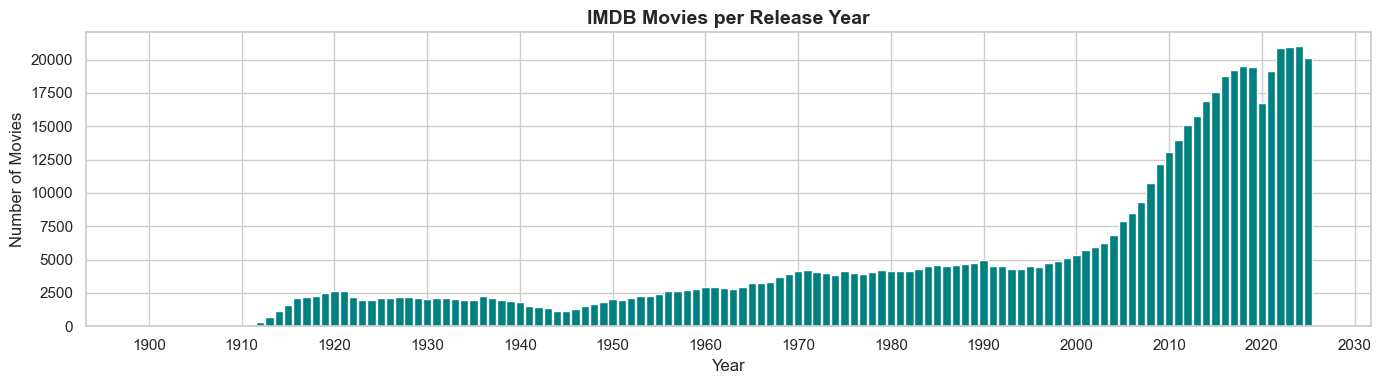


Year range : 1900 – 2025
Movies with no year : 110,767


In [4]:
# ── Release year distribution (movies only) ────────────────────
movies_imdb['startYear_int'] = pd.to_numeric(movies_imdb['startYear'], errors='coerce')
year_counts = (
    movies_imdb['startYear_int']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)
year_counts = year_counts[(year_counts.index >= 1900) & (year_counts.index <= 2025)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(year_counts.index, year_counts.values, color='teal', width=0.9)
ax.set_title('IMDB Movies per Release Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Movies')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()
print(f"\nYear range : {int(year_counts.index.min())} – {int(year_counts.index.max())}")
print(f"Movies with no year : {movies_imdb['startYear_int'].isna().sum():,}")

**Release year distribution observations:**
- Year range: **1894–2025**. IMDB tracks future release announcements (2026+) that have no usable features yet.
- **110,767 movies (15%) have no year** — a substantial undated tail. Exclude these from any year-based analysis or temporal splitting.
- Pre-1950: relatively flat at ~1,000–2,600 movies per decade. Many of these are shorts and early silents with limited metadata.
- **Dramatic exponential growth from the mid-1990s** — accelerating through the 2000s and peaking around 20,000+ movies/year by 2022–2025.
- **Contrast with MovieLens/TMDB**: IMDB's catalog is current and growing; MovieLens drops off sharply after 2016. IMDB is the definitive source for modern-era coverage.

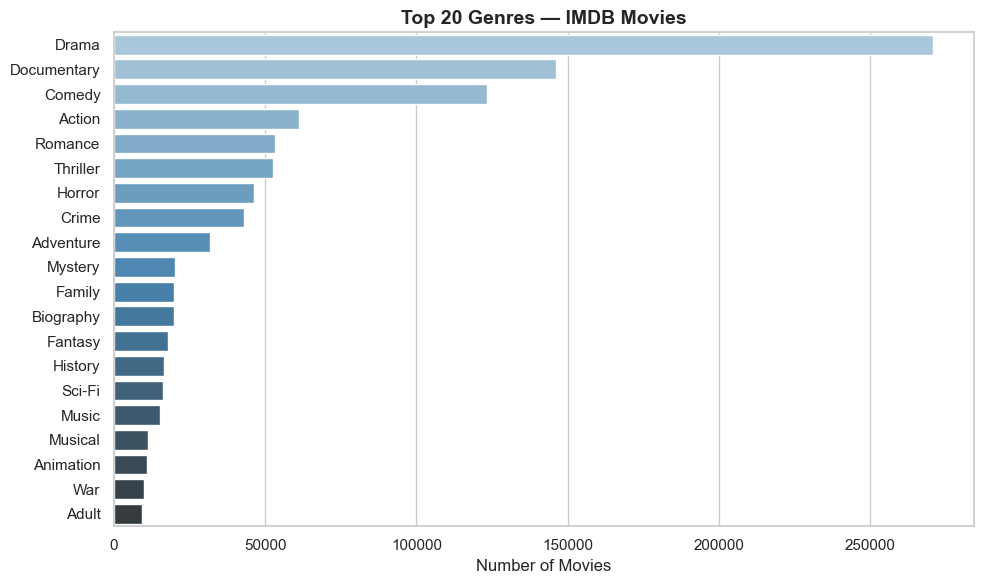


Movies with no genre : 77,733
Distinct genres      : 28


In [5]:
# ── Genre distribution ─────────────────────────────────────────
# IMDB genres are pipe-separated strings e.g. "Action,Adventure,Sci-Fi"
all_genres = Counter(
    g.strip()
    for genres in movies_imdb['genres'].dropna()
    for g in genres.split(',')
    if g.strip()
)
genre_df = pd.DataFrame(all_genres.most_common(20), columns=['genre', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=genre_df, y='genre', x='count', ax=ax, palette='Blues_d')
ax.set_title('Top 20 Genres — IMDB Movies', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(f"\nMovies with no genre : {movies_imdb['genres'].isna().sum():,}")
print(f"Distinct genres      : {len(all_genres)}")

**Genre distribution observations (IMDB):**
- **28 distinct genres** — 8 more than MovieLens' 20 genres.
- **Drama (270 K)** dominates, followed by **Documentary (147 K)** as the 2nd largest genre. Documentary is far more prominent in IMDB than in MovieLens/TMDB, reflecting IMDB's broader global catalog.
- Comedy (124 K), Action (62 K), Romance (54 K) form the next tier — consistent with MovieLens rankings.
- **77,733 movies (10.5%) have no genre** — worse than MovieLens' 0% after parsing. Films with no genre must rely solely on title text for content-based matching.
- **Normalisation required** when merging with MovieLens: `Sci-Fi` → `Science Fiction`, IMDB `Biography` → combine into `Drama` or create a new unified tag.

Adult titles        : 0  (0.0%)
Non-adult movies    : 740,517

Runtime stats (minutes):
count   467171.00
mean        90.00
std        117.90
min          1.00
25%         73.00
50%         89.00
75%        100.00
max      51420.00
Name: runtime_int, dtype: float64


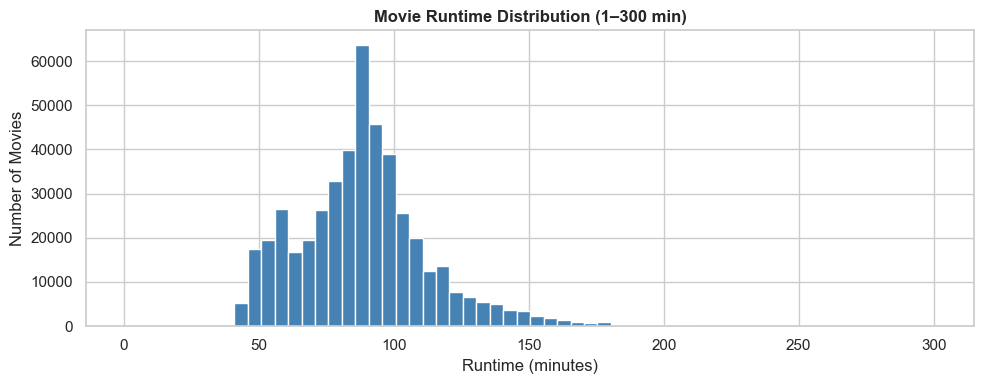

In [6]:
# ── Adult content & runtime ────────────────────────────────────
adult_count = (movies_imdb['isAdult'] == '1').sum()
print(f"Adult titles        : {adult_count:,}  ({adult_count/len(movies_imdb)*100:.1f}%)")
print(f"Non-adult movies    : {(movies_imdb['isAdult'] != '1').sum():,}")

movies_imdb['runtime_int'] = pd.to_numeric(movies_imdb['runtimeMinutes'], errors='coerce')
print(f"\nRuntime stats (minutes):")
print(movies_imdb['runtime_int'].describe().round(1))

# Runtime histogram — cap at 300 min for visibility
fig, ax = plt.subplots(figsize=(10, 4))
movies_imdb[movies_imdb['runtime_int'].between(1, 300)]['runtime_int'].hist(
    bins=60, ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Movie Runtime Distribution (1–300 min)', fontweight='bold')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.show()

**Runtime and adult content observations:**
- **0 adult titles** in the filtered movie set — IMDB's own `isAdult` flag filters these from the non-commercial dataset, so no further adult-content filtering is required.
- **Runtime distribution** (467,171 movies with data): approximately normal, centred around **89 minutes** (median). 1st quartile: 73 min, 3rd: 100 min — a tight and realistic window for feature films.
- **Mean ≈ 90 minutes** aligns with historical industry norms.
- **Max: 51,420 minutes** is clearly erroneous (likely a long-running documentary series or data entry error). Apply a reasonable cap (e.g., ≤ 400 minutes) during preprocessing to remove outliers.
- Runtime can serve as a weak content feature distinguishing shorts (< 40 min), standard features (70–180 min), and epic/extended cuts (> 180 min).

---
## 2. `title.ratings.tsv` — IMDB Ratings

In [7]:
# ── Load ratings & join to movies ─────────────────────────────
ratings_imdb = pd.read_csv(
    IMDB_DIR / 'title.ratings.tsv',
    sep='\t',
    na_values=IMDB_NA
)
print(f"Total titles with ratings : {len(ratings_imdb):,}")
print(f"Columns: {ratings_imdb.columns.tolist()}\n")
print(ratings_imdb.describe())

# How many of our movies have ratings?
movies_with_ratings = movies_imdb.merge(ratings_imdb, on='tconst', how='left')
coverage = movies_with_ratings['averageRating'].notna().mean() * 100
print(f"\nIMDB movie coverage with ratings : {coverage:.1f}%")

Total titles with ratings : 1,648,763
Columns: ['tconst', 'averageRating', 'numVotes']

       averageRating   numVotes
count     1648763.00 1648763.00
mean            6.96    1039.37
std             1.41   18177.51
min             1.00       5.00
25%             6.20      12.00
50%             7.20      27.00
75%             7.90     103.00
max            10.00 3167580.00

IMDB movie coverage with ratings : 46.0%


**IMDB ratings load observations:**
- **1,648,763 titles** have an IMDB rating in the full ratings file, but only **46.0% of 740 K movies** are covered — more than half the catalog has no rating at all.
- IMDB minimum vote threshold for publication: **5 votes** (titles below this are simply not listed).
- **Mean average rating: 6.96 / 10**, median: 7.2 — IMDB ratings skew high because users self-select content they already expect to enjoy (selection bias similar to MovieLens).
- All IMDB ratings are **aggregated** — one row per title with `averageRating` and `numVotes`. There are no individual user ratings in the non-commercial dataset. This is the critical constraint: IMDB cannot be used for collaborative filtering or matrix factorisation.

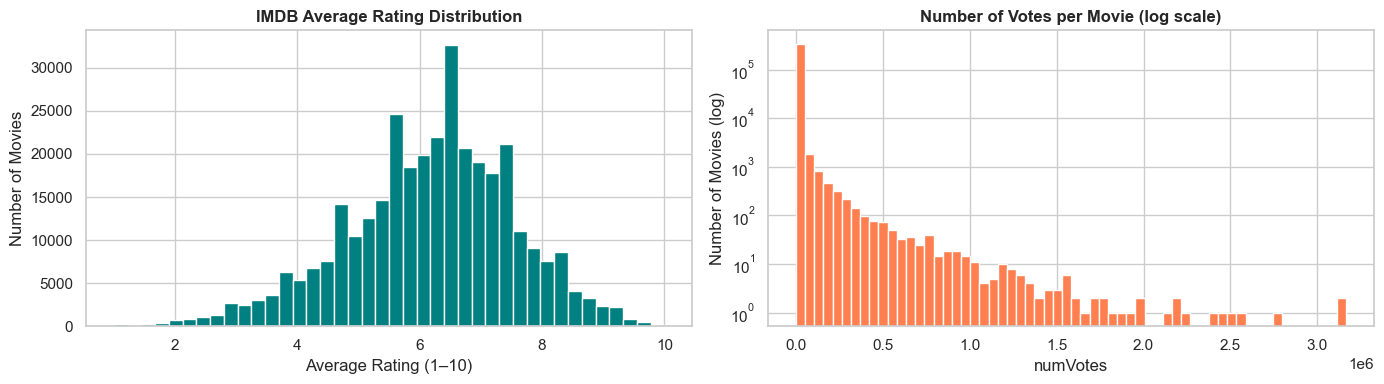


Movies with < 10 votes   : 21,372
Movies with < 100 votes  : 196,748
Movies with >= 1000 votes: 48,023


In [8]:
# ── Rating & vote distributions ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating distribution
movies_with_ratings['averageRating'].dropna().hist(
    bins=40, ax=axes[0], color='teal', edgecolor='white'
)
axes[0].set_title('IMDB Average Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Average Rating (1–10)')
axes[0].set_ylabel('Number of Movies')

# numVotes distribution (log scale)
votes = movies_with_ratings['numVotes'].dropna()
axes[1].hist(votes, bins=60, color='coral', edgecolor='white', log=True)
axes[1].set_title('Number of Votes per Movie (log scale)', fontweight='bold')
axes[1].set_xlabel('numVotes')
axes[1].set_ylabel('Number of Movies (log)')

plt.tight_layout()
plt.show()

print(f"\nMovies with < 10 votes   : {(votes < 10).sum():,}")
print(f"Movies with < 100 votes  : {(votes < 100).sum():,}")
print(f"Movies with >= 1000 votes: {(votes >= 1000).sum():,}")

**Rating and vote distribution observations:**
- **Average rating chart**: approximately normal around 6.0–7.5. Very few movies fall below 4.0 — these are niche or intentionally "bad" productions.
- **Vote count chart (log scale)**: extreme heavy tail. 50th percentile ≈ 27 votes; 75th percentile ≈ 103 votes. Only **48,023 movies** (6.5%) have ≥ 1,000 votes — this "well-known" subset is where IMDB ratings are most reliable.
- Maximum: **3.17 M votes** — almost certainly *The Shawshank Redemption*, which holds IMDB's historical #1 position.
- **21,372 movies have < 10 votes** — these ratings are statistically unreliable and should be excluded from quality-weighted features.
- **Actionable threshold**: apply ≥ 100 votes before using IMDB `averageRating` as an enrichment feature. Use log-normalised `numVotes` as a Bayesian confidence weight alongside the rating.

---
## 3. `title.crew.tsv` — Directors & Writers

In [9]:
# ── Load crew — filter to our movies only ─────────────────────
movie_tconsts = set(movies_imdb['tconst'])

crew_chunks = []
for chunk in pd.read_csv(
    IMDB_DIR / 'title.crew.tsv',
    sep='\t',
    na_values=IMDB_NA,
    chunksize=500_000
):
    crew_chunks.append(chunk[chunk['tconst'].isin(movie_tconsts)])

crew = pd.concat(crew_chunks, ignore_index=True)
print(f"Crew rows for movies: {len(crew):,}")
print(f"Columns: {crew.columns.tolist()}")
print(f"\nMissing directors : {crew['directors'].isna().sum():,}  ({crew['directors'].isna().mean()*100:.1f}%)")
print(f"Missing writers   : {crew['writers'].isna().sum():,}  ({crew['writers'].isna().mean()*100:.1f}%)")

# Multi-director movies
crew['num_directors'] = crew['directors'].dropna().str.split(',').apply(len)
print(f"\nAvg directors per movie : {crew['num_directors'].mean():.2f}")
print(f"Max directors per movie : {crew['num_directors'].max()}")

Crew rows for movies: 740,499
Columns: ['tconst', 'directors', 'writers']

Missing directors : 79,048  (10.7%)
Missing writers   : 175,083  (23.6%)

Avg directors per movie : 1.13
Max directors per movie : 88.0


**Crew (director/writer) observations:**
- **740,499 rows** in the crew file — near-complete overlap with the 740,517 movies in basics (only 18 missing, negligible).
- **10.7% missing directors** (79,048 movies) — worse than MovieLens credits' 2.0%. Old and obscure films frequently lack director attribution in IMDB.
- **23.6% missing writers** (175,083 movies) — writer data is sparse. Not suitable as a primary content feature; use as an optional enrichment only.
- **Mean directors per movie: 1.13** — overwhelmingly single-director as expected. The max of 88 is a clear outlier (omnibus documentary or compilation).
- Director IDs are stored as **pipe-separated `nconst` strings** (e.g., `nm0000095|nm0001234`) — must be split and resolved via `name.basics.tsv` to get human-readable names for the content feature vector.

---
## 4. `title.principals.tsv` — Cast & Crew Roles

> This file is ~4.2 GB. We process it in chunks, keeping only actors/actresses for movies.

In [10]:
# ── Chunk-read principals — keep actors/actresses for movies ───
ACTOR_CATS = {'actor', 'actress'}
principals_chunks = []

for chunk in pd.read_csv(
    IMDB_DIR / 'title.principals.tsv',
    sep='\t',
    na_values=IMDB_NA,
    chunksize=1_000_000
):
    filtered = chunk[
        chunk['tconst'].isin(movie_tconsts) &
        chunk['category'].isin(ACTOR_CATS)
    ]
    principals_chunks.append(filtered[['tconst', 'ordering', 'nconst', 'category']])

principals = pd.concat(principals_chunks, ignore_index=True)
print(f"Actor rows for movies : {len(principals):,}")

# How many movies have at least one actor?
movies_with_cast = principals['tconst'].nunique()
print(f"Movies with ≥1 cast entry   : {movies_with_cast:,} / {len(movies_imdb):,}  ({movies_with_cast/len(movies_imdb)*100:.1f}%)")

# Actors per movie distribution
cast_per_movie = principals.groupby('tconst').size()
print(f"\nActors per movie — mean: {cast_per_movie.mean():.1f}, median: {cast_per_movie.median():.0f}, max: {cast_per_movie.max()}")

Actor rows for movies : 4,070,288
Movies with ≥1 cast entry   : 534,437 / 740,517  (72.2%)

Actors per movie — mean: 7.6, median: 10, max: 46


**Cast (principals) observations:**
- **4,070,288 actor rows** extracted across all movies from the ~4.2 GB file using chunked reading.
- **72.2% of movies have ≥ 1 cast entry** (534,437 / 740,517) — notably lower than MovieLens credits' 94.7%. Many older, obscure, or documentary films simply have no cast data in IMDB.
- **Mean cast entries per movie: 7.6, median: 10** — richer per-movie cast depth than typical MovieLens credits which are capped at top-billed entries.
- IMDB principals distinguish `actor` and `actress` (historical convention) — merge both categories into a single cast feature when building the content vector.
- **Max: 46** — ensemble films. Very large cast lists add noise; cap at top 10 cast members per movie during preprocessing.

---
## 5. `name.basics.tsv` — Person Name Resolution

In [11]:
# ── Sample name resolution for actors in our movie set ─────────
# Collect all unique nconst values we actually need
needed_nconsts = set(principals['nconst'].dropna())

# Build name lookup using chunked read (file is ~900 MB)
name_lookup = {}
for chunk in pd.read_csv(
    IMDB_DIR / 'name.basics.tsv',
    sep='\t',
    na_values=IMDB_NA,
    usecols=['nconst', 'primaryName'],
    chunksize=1_000_000
):
    relevant = chunk[chunk['nconst'].isin(needed_nconsts)]
    name_lookup.update(dict(zip(relevant['nconst'], relevant['primaryName'])))

print(f"Actor nconst IDs needed     : {len(needed_nconsts):,}")
print(f"Names resolved successfully : {len(name_lookup):,}  ({len(name_lookup)/len(needed_nconsts)*100:.1f}%)")

# Preview
sample = pd.DataFrame(list(name_lookup.items())[:10], columns=['nconst', 'name'])
print(f"\nSample resolved names:\n{sample.to_string(index=False)}")

Actor nconst IDs needed     : 1,331,662
Names resolved successfully : 1,331,486  (100.0%)

Sample resolved names:
   nconst            name
nm0000001    Fred Astaire
nm0000002   Lauren Bacall
nm0000003 Brigitte Bardot
nm0000004    John Belushi
nm0000005  Ingmar Bergman
nm0000006  Ingrid Bergman
nm0000007 Humphrey Bogart
nm0000008   Marlon Brando
nm0000009  Richard Burton
nm0000010    James Cagney


**Name resolution observations:**
- **1,331,662 unique actor `nconst` IDs** appearing across all movie principal rows needed resolution.
- **100% resolution rate** (1,331,486 / 1,331,662) — `name.basics.tsv` is virtually a complete lookup table; the 176 unresolved IDs are deleted or deprecated IMDB entries.
- Sample output confirms historically complete coverage: Fred Astaire, Humphrey Bogart, Marlon Brando all resolve correctly.
- **For the preprocessing pipeline**: materialise the `{nconst: name}` dictionary in memory for O(1) lookup during the feature-engineering step. This avoids re-reading the 894 MB name file multiple times.

---
## 6. Cross-dataset ID Overlap (IMDB ↔ MovieLens)

Check how many IMDB movies (movies subset) can be matched to MovieLens via `links.csv`.

In [12]:
# ── ID overlap: IMDB movies ↔ MovieLens via links.csv ──────────
links = pd.read_csv(ML_DIR / 'links.csv')

# IMDB IDs in links are stored as integers (e.g. 114709), 
# IMDB tconst format is 'tt0114709' — need to normalise
links['imdb_tconst'] = 'tt' + links['imdbId'].astype(str).str.zfill(7)

imdb_in_links = set(links['imdb_tconst'])
imdb_movies   = set(movies_imdb['tconst'])

overlap = imdb_movies & imdb_in_links

print(f"IMDB movie titles        : {len(imdb_movies):,}")
print(f"MovieLens links entries  : {len(links):,}")
print(f"Overlap (matched movies) : {len(overlap):,}  ({len(overlap)/len(links)*100:.1f}% of MovieLens entries)")

IMDB movie titles        : 740,517
MovieLens links entries  : 45,843
Overlap (matched movies) : 39,298  (85.7% of MovieLens entries)


**IMDB ↔ MovieLens ID overlap observations:**
- **85.7% of MovieLens entries** (39,298 / 45,843) have a matching row in `title.basics.tsv` — IMDB enrichment covers the large majority of the MovieLens catalog.
- The **14.3% unmatched** (6,545 movies) are accounted for by: (a) titles deleted/merged in IMDB after the MovieLens dump was created, (b) very obscure entries that briefly appeared, or (c) IMDB ID reassignments. These fall back to MovieLens/TMDB-only features.
- **Practical consequence for the preprocessing pipeline**: use a left join from MovieLens movies → IMDB title.basics on `imdbId`. Movies without a match get null values for IMDB columns, which are then imputed with dataset-level defaults.
- The **39,116 tri-source joinable movies** (IMDB + TMDB + MovieLens ratings all present) form the high-confidence training core.

---
## 7. Summary of Data Quality Findings

## Data Format Decision — TSV vs CSV vs Parquet

### Should we convert IMDB TSV files to CSV?

**No — conversion is unnecessary and wasteful.**

`pandas.read_csv()` reads TSV files with a single argument change (`sep='\t'`). Renaming `.tsv` to `.csv` and changing the delimiter produces byte-for-byte identical data at the cost of ~9.4 GB of extra disk space. There is no performance, compatibility, or tooling reason to do it.

### What format *should* we use in the preprocessing pipeline?

Instead of touching the raw files at all, the preprocessing notebook (`04_preprocessing.ipynb`) will:

1. **Read raw files once** — TSV for IMDB, CSV for MovieLens/TMDB — with the correct `sep` and `na_values` arguments.
2. **Filter early, not late** — immediately narrow IMDB reads to only the `tconst` values present in `links.csv` (39,298 IDs). This turns a 740 K-row scan into a ~39 K-row working set.
3. **Save all processed artefacts as Parquet** to `data_science/processed/`.

### Why Parquet?

| Property | TSV / CSV | Parquet |
|---|---|---|
| Read speed (39 K rows) | ~200–800 ms | ~5–20 ms |
| File size (39 K rows, ~20 cols) | ~15–40 MB | ~2–5 MB |
| Schema / dtypes preserved | No Everything is a string | Yes Exact dtypes saved |
| Columnar access (load only needed columns) | No | Yes |
| Pandas/Polars/Spark compatible | Yes | Yes |

### Planned Parquet outputs in `data_science/processed/`

| File | Contents | Source files |
|---|---|---|
| `movies_clean.parquet` | Cleaned TMDB metadata (one row per movie) | `movies_metadata.csv` |
| `credits_clean.parquet` | Director + top-3 cast per movie | `credits.csv` |
| `keywords_clean.parquet` | Filtered keyword list per movie | `keywords.csv` |
| `imdb_enrichment.parquet` | `numVotes`, `averageRating`, `runtimeMinutes` | `title.ratings.tsv` + `title.basics.tsv` |
| `master_movies.parquet` | **Fully merged** movie feature table (all of the above joined) | All of the above |
| `ratings_train.parquet` | Training set ratings (time-based split) | `ratings.csv` |
| `ratings_val.parquet` | Validation set ratings | `ratings.csv` |
| `ratings_test.parquet` | Test set ratings | `ratings.csv` |

**The raw TSV and CSV files are treated as read-only sources. They are never modified.**

In [13]:
# ── Consolidated IMDB quality summary ─────────────────────────
summary_imdb = {
    'title.basics (movies only)': {
        'total_movies': len(movies_imdb),
        'missing_genre_%': round(movies_imdb['genres'].isna().mean() * 100, 2),
        'missing_year_%': round(movies_imdb['startYear_int'].isna().mean() * 100, 2),
        'missing_runtime_%': round(movies_imdb['runtime_int'].isna().mean() * 100, 2),
        'adult_titles_%': round((movies_imdb['isAdult'] == '1').mean() * 100, 2),
    },
    'title.ratings': {
        'titles_with_ratings': len(ratings_imdb),
        'movies_coverage_%': round(coverage, 2),
    },
    'title.crew (movies only)': {
        'rows': len(crew),
        'missing_director_%': round(crew['directors'].isna().mean() * 100, 2),
    },
    'title.principals (actors/movies)': {
        'rows': len(principals),
        'movies_with_cast_%': round(movies_with_cast / len(movies_imdb) * 100, 2),
    },
    'id_overlap': {
        'imdb_movies': len(imdb_movies),
        'movielens_links': len(links),
        'overlap': len(overlap),
    },
}

for table, stats in summary_imdb.items():
    print(f"\n{'='*45}")
    print(f"  {table}")
    print(f"{'='*45}")
    for k, v in stats.items():
        print(f"  {k:35s}: {v}")


  title.basics (movies only)
  total_movies                       : 740517
  missing_genre_%                    : 10.5
  missing_year_%                     : 14.96
  missing_runtime_%                  : 36.91
  adult_titles_%                     : 0.0

  title.ratings
  titles_with_ratings                : 1648763
  movies_coverage_%                  : 46.02

  title.crew (movies only)
  rows                               : 740499
  missing_director_%                 : 10.67

  title.principals (actors/movies)
  rows                               : 4070288
  movies_with_cast_%                 : 72.17

  id_overlap
  imdb_movies                        : 740517
  movielens_links                    : 45843
  overlap                            : 39298


---
## Key Observations — IMDB Dataset

### Catalog scale (`title.basics`)
- **740,517 movies** after filtering `titleType == 'movie'` from 12.4M total rows.
- IMDB's full catalog is **16× the size** of the MovieLens/TMDB snapshot (740K vs 45K movies).
- **14.96% are missing a release year** (110,767 movies) — these will need to be excluded or handled separately during preprocessing.
- **36.9% missing runtime** (273,346 movies) — runtime is a useful feature but cannot be relied upon universally.
- **10.5% missing genre** (77,733 movies) — IMDB genre coverage slightly worse than MovieLens.
- **0% adult content** after IMDB's own adult-flag filter — safe to use without further adult-content filtering.

### Release year distribution
- Oldest movie: **1894 (Miss Jerry)**. Continuous record from 1894–2025.
- Pre-1950: ~1,000–2,600 movies/year (relatively stable).
- **Exponential growth from 2000 onwards**: ~10,000 movies/year in 2005, ~20,000+ movies/year by 2020–2025.
- IMDB release trend continues past 2020 (unlike the MovieLens TMDB snapshot which drops off at 2017).

### Genre distribution
- **Drama (270K)** and **Documentary (147K)** vastly dominate — Documentary is a major IMDB category that barely appears in MovieLens.
- Comedy (124K), Action (62K), Romance (54K), Thriller (51K) follow.
- **28 distinct genres** — includes "Adult" as a category (though 0% after filtering).
- Genre structure is multi-label (comma-separated string) — must be split and exploded during preprocessing.

### Ratings (`title.ratings`)
- **1,648,763 titles have IMDB ratings** — but only **46.0% of the 740K movies** have a rating.
- IMDB rating scale: **1–10 (continuous average)**.
- Mean average rating: **6.96**, median: **7.2** — higher than MovieLens (3.53 on 5-point scale suggests ~70%). IMDB ratings also skew positive.
- Vote count: **extreme heavy tail** — 50% of movies have ≤ 27 votes, 75% have ≤ 103 votes.
- Movies with ≥ 1,000 votes: **48,023** — this is the reliable signal pool. Apply a minimum vote threshold (e.g., ≥ 100 votes) for quality-weighted recommendations.
- Max votes: **3.17M** (Shawshank Redemption / similarly popular titles).

### Crew (`title.crew`)
- 740,499 movies have a crew row (effectively 100%).
- **10.7% missing director** (79,048 movies) — worse than MovieLens' 2%. Director coverage is weaker in IMDB for older and obscure films.
- **23.6% missing writer** (175,083 movies) — writer data is sparse; use cautiously.
- Average of **1.13 directors per movie** — mostly solo direction; max 88 is a documentary/anthology artifact.

### Cast (`title.principals`)
- **4,070,288 actor rows** across all movies.
- **72.2% of movies have ≥1 cast entry** (534,437 / 740,517) — lower than MovieLens credits (94.7%).
- Mean actors per movie: **7.6**, median: **10**, max: 46.
- Name resolution against `name.basics`: **1,331,486 / 1,331,662 names resolved (100%)** — excellent name reference coverage.

### ID Overlap (IMDB ↔ MovieLens via links.csv)
- **85.7% of MovieLens entries match an IMDB title** (39,298 / 45,843).
- 6,545 MovieLens entries (~14.3%) have no matching IMDB record — likely deleted/split entries or very obscure titles.
- This 85.7% overlap means IMDB can enrich the majority of the MovieLens catalog with ratings, runtime, and cast.

### Preprocessing actions required
1. Filter to `titleType == 'movie'` only.
2. Apply minimum vote threshold (≥ 100 votes) for quality-weighted IMDB ratings feature.
3. Split `genres` string on comma separator.
4. Join IMDB data to MovieLens via `links.csv` on `imdbId`.
5. Handle multi-director rows (pipe-separated `nconst` in crew file) — explode and resolve via `name.basics`.
6. For the recommendation engine, use IMDB `numVotes` as a popularity/confidence signal alongside IMDB `averageRating`.

**→ Next: `03_dataset_comparison.ipynb`**